# L15c: From Time Stepping to State-Space and Learned Dynamics

Discretization creates a bridge from continuous engineering models to the discrete state updates used throughout modern sequence and state-space methods.

> **Learning objectives**
>
> - Convert a continuous linear model into an Euler state update.
> - Use eigenvalues to diagnose discrete-time stability.
> - Separate known mechanistic updates from learned update functions.
> - Identify the precise prerequisite handoff to CHEME 5820.


## Setup

Run the local setup cell first. It activates the pinned course environment, loads every package used by this meeting, and includes the `Week15Core` module from [`../src/Week15Core.jl`](../src/Week15Core.jl), which provides the functions called below.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes the meeting's local source. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:


In [1]:
include(joinpath(@__DIR__, "Include.jl"))


## Continuous model to discrete update

For `dx/dt = Ax`, explicit Euler produces

$$x_{k+1}=(I+\Delta t A)x_k=A_d x_k.$$

The continuous generator `A`, the step size, and the discretization method jointly determine the discrete update matrix `A_d`.


In [2]:
A = [-0.4 1.0; -1.0 -0.4]
dt = 0.05
Ad = linear_discretization(A, dt)
DataFrame(
    object = ["continuous A", "Euler Ad"],
    eigenvalues = [eigvals(A), eigvals(Ad)],
    largest_magnitude = [maximum(abs.(eigvals(A))), maximum(abs.(eigvals(Ad)))],
)


Row,object,eigenvalues,largest_magnitude
,String,Array…,Float64
1,continuous A,"ComplexF64[-0.4-1.0im, -0.4+1.0im]",1.07703
2,Euler Ad,"ComplexF64[0.98-0.05im, 0.98+0.05im]",0.981275


In [3]:
discrete_states = linear_rollout(Ad, [1.0, 0.0], 200)
continuous_rhs(u, t, A) = A * u
continuous = library_integrate(
    continuous_rhs,
    [1.0, 0.0],
    (0.0, 10.0);
    p = A,
    saveat = dt,
)
maximum(abs.(discrete_states .- continuous.u))


0.027710310090116097

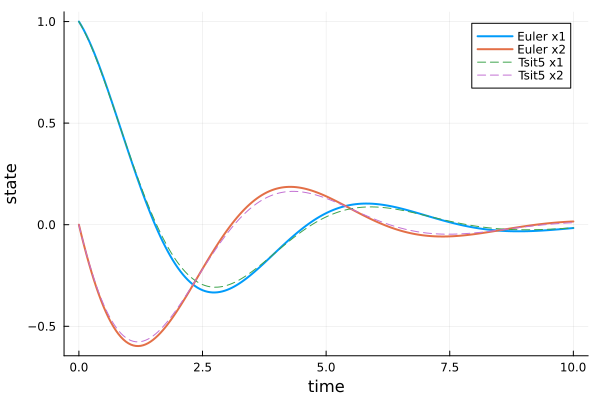

In [4]:
times = collect(0.0:dt:10.0)
plot(times, discrete_states; label = ["Euler x1" "Euler x2"], linewidth = 2)
plot!(continuous.t, continuous.u; label = ["Tsit5 x1" "Tsit5 x2"], linestyle = :dash)
xlabel!("time")
ylabel!("state")


## Known versus learned updates

- **Mechanistic update:** `x[k+1] = F(x[k], u[k], parameters)` is derived from a physical model and numerical method.
- **Learned update:** parameters or the function `F` are estimated from data.
- **Hybrid update:** known conservation or transport structure is combined with a learned closure.

All three still require state definitions, training or calibration data, validation evidence, and stability/robustness checks.


In [5]:
bridge = DataFrame(
    fall_foundation = [
        "SVD and regression",
        "optimization and tested programs",
        "Markov decisions and Q-learning",
        "time discretization and state updates",
    ],
    spring_extension = [
        "learned features and neural models",
        "training algorithms and backpropagation",
        "deep reinforcement learning",
        "recurrent, state-space, and spiking models",
    ],
)
bridge


Row,fall_foundation,spring_extension
,String,String
1,SVD and regression,learned features and neural models
2,optimization and tested programs,training algorithms and backpropagation
3,Markov decisions and Q-learning,deep reinforcement learning
4,time discretization and state updates,"recurrent, state-space, and spiking models"


## Boundary statement

Fall 5800 supplies numerical state updates, linear algebra, optimization, validation, and tabular sequential decisions. Spring 5820 owns neural architectures, backpropagation, embeddings, recurrent/state-space/spiking systems, and deep reinforcement learning. This bridge names prerequisites; it does not compress the Spring course into one lecture.
